In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv(r"C:\Users\Tejaswi.k\OneDrive\Desktop\datascience coaching\ml\csv files\airlines_customer_satisfaction.csv")

In [3]:
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [4]:
##apply median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)


In [5]:
# # Remove unnecessary dataset
df.drop(['Unnamed: 0', 'id'],axis=1, inplace=True)

In [6]:
##label encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [7]:
##Split Features and Target
x = df.drop('satisfaction', axis=1)
y = df['satisfaction']

In [8]:
print(x.shape)
print(y.shape)

(103904, 22)
(103904,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred = lr.predict(x_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred) * 100)

Logistic Regression Accuracy: 87.84525069771918


In [26]:
train_pred = lr.predict(x_train_scaled)

print("Train Accuracy:",
      accuracy_score(y_train, train_pred) * 100)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred) * 100)

Train Accuracy: 87.50548052142483
Test Accuracy: 87.84525069771918


In [27]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[5423  557]
 [ 706 3705]]


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      5980
           1       0.87      0.84      0.85      4411

    accuracy                           0.88     10391
   macro avg       0.88      0.87      0.88     10391
weighted avg       0.88      0.88      0.88     10391



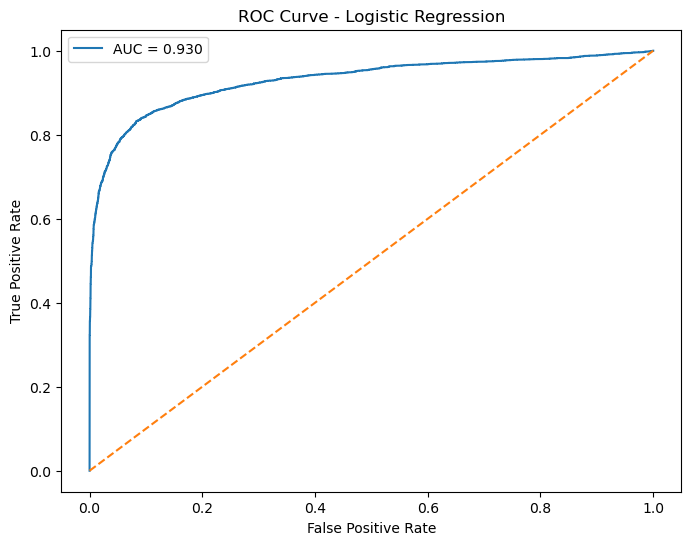

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = lr.predict_proba(x_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [30]:
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_[0]
})

print(coef_df.sort_values(by='Coefficient', ascending=False))

                              Feature  Coefficient
11                    Online boarding     0.834279
6               Inflight wifi service     0.509443
17                    Checkin service     0.414270
14                   On-board service     0.396910
15                   Leg room service     0.327511
19                        Cleanliness     0.291732
16                   Baggage handling     0.163343
20         Departure Delay in Minutes     0.151857
18                   Inflight service     0.139831
12                       Seat comfort     0.093922
13             Inflight entertainment     0.072912
9                       Gate location     0.041203
0                              Gender     0.019947
5                     Flight Distance    -0.002116
10                     Food and drink    -0.033889
2                                 Age    -0.120841
7   Departure/Arrival time convenient    -0.192617
8              Ease of Online booking    -0.199607
4                              